In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.combine import SMOTETomek

In [ ]:
#loading dataset
df = pd.read_csv("star_classification.csv")
print(df.head())
print(df.info())

         obj_ID       alpha      delta         u         g         r  \
0  1.237661e+18  135.689107  32.494632  23.87882  22.27530  20.39501   
1  1.237665e+18  144.826101  31.274185  24.77759  22.83188  22.58444   
2  1.237661e+18  142.188790  35.582444  25.26307  22.66389  20.60976   
3  1.237663e+18  338.741038  -0.402828  22.13682  23.77656  21.61162   
4  1.237680e+18  345.282593  21.183866  19.43718  17.58028  16.49747   

          i         z  run_ID  rerun_ID  cam_col  field_ID   spec_obj_ID  \
0  19.16573  18.79371    3606       301        2        79  6.543777e+18   
1  21.16812  21.61427    4518       301        5       119  1.176014e+19   
2  19.34857  18.94827    3606       301        2       120  5.152200e+18   
3  20.50454  19.25010    4192       301        3       214  1.030107e+19   
4  15.97711  15.54461    8102       301        3       137  6.891865e+18   

    class  redshift  plate    MJD  fiber_ID  
0  GALAXY  0.634794   5812  56354       171  
1  GALAXY  0.77913

In [ ]:
#Removing noise 
noise_columns = [
    'obj_ID',
    'spec_obj_ID',
    'run_ID',
    'rerun_ID',
    'cam_col',
    'field_ID',
    'plate',
    'MJD',
    'fiber_ID'
]

In [ ]:
df = df.drop(columns=noise_columns)
print(df.columns)

Index(['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'class', 'redshift'], dtype='object')


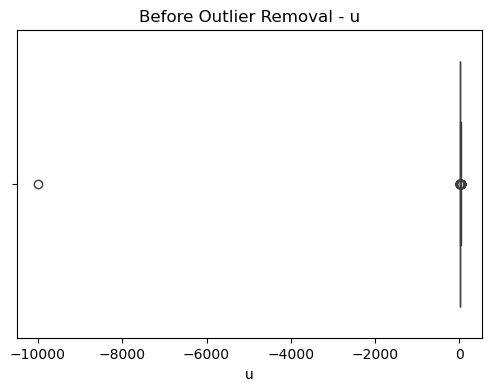

In [ ]:
#EDA 
feature = 'u'

plt.figure(figsize=(6,4))
sns.boxplot(x=df[feature])
plt.title('Before Outlier Removal - u')
plt.show()

Shape after outlier removal: (90600, 9)


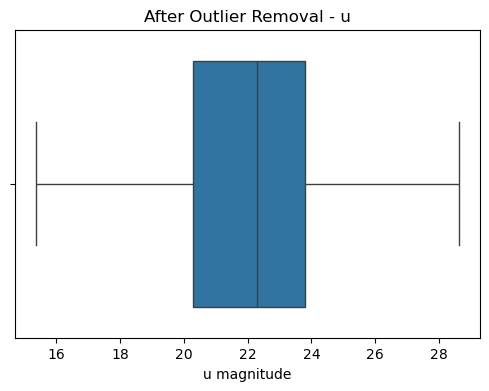

In [ ]:
# Outlier removal using IQR for all numeric features
numeric_cols = df.select_dtypes(include=[np.number]).columns

df_clean = df.copy()

for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    df_clean = df_clean[
        (df_clean[col] >= Q1 - 1.5 * IQR) &
        (df_clean[col] <= Q3 + 1.5 * IQR)
    ]

print("Shape after outlier removal:", df_clean.shape)
import matplotlib.pyplot as plt
import seaborn as sns

# After outlier removal for 'u' feature
plt.figure(figsize=(6,4))
sns.boxplot(x=df_clean['u'])
plt.title('After Outlier Removal - u')
plt.xlabel('u magnitude')
plt.show()


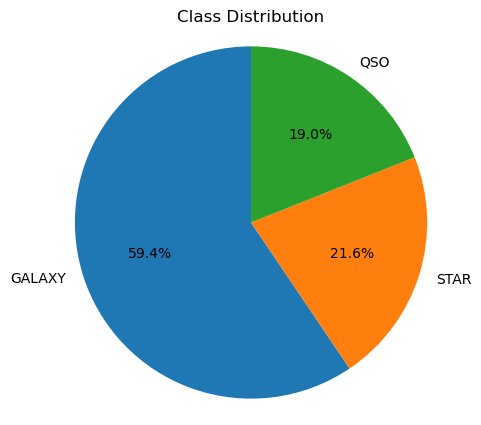

In [ ]:
#Visualization:
class_counts = df['class'].value_counts()

plt.figure(figsize=(5,5))
plt.pie(
    class_counts,
    labels=class_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Class Distribution')
plt.axis('equal')
plt.show()


In [ ]:
#Feature and Target separation:
X = df_clean.drop("class", axis=1)
y = df_clean["class"]


print(X.shape)
print(y.shape)

(90600, 8)
(90600,)


In [ ]:
#Train test and split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Handle class imbalance
from imblearn.combine import SMOTETomek

smote_tomek = SMOTETomek(random_state=42)

X_train_res, y_train_res = smote_tomek.fit_resample(
    X_train_scaled, y_train
)

print("Resampled distribution:")
print(pd.Series(y_train_res).value_counts())


Resampled distribution:
class
STAR      47225
QSO       47158
GALAXY    47088
Name: count, dtype: int64


In [ ]:
#LOGISTIC REGRESSION:
from sklearn.model_selection import GridSearchCV

log_reg = LogisticRegression(
    max_iter=2000,
    solver='lbfgs'
)


param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs']
}

grid_lr = GridSearchCV(
    log_reg,
    param_grid_lr,
    cv=5,
    scoring='f1_macro'
)

grid_lr.fit(X_train_res, y_train_res)

best_lr = grid_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import f1_score

print("🔹 Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Macro F1:", f1_score(y_test, y_pred_lr, average='macro'))
print("Weighted F1:", f1_score(y_test, y_pred_lr, average='weighted'))
print(classification_report(y_test, y_pred_lr))



🔹 Logistic Regression Results
Accuracy: 0.9383554083885209
Macro F1: 0.9065223052057657
Weighted F1: 0.9406485276990215
              precision    recall  f1-score   support

      GALAXY       0.98      0.92      0.95     11824
         QSO       0.70      0.89      0.79      1994
        STAR       0.97      1.00      0.98      4302

    accuracy                           0.94     18120
   macro avg       0.88      0.94      0.91     18120
weighted avg       0.95      0.94      0.94     18120



In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

print("🔹 Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Macro F1:", f1_score(y_test, y_pred_rf, average='macro'))
print("Weighted F1:", f1_score(y_test, y_pred_rf, average='weighted'))
print(classification_report(y_test, y_pred_rf))


🔹 Random Forest Results
Accuracy: 0.9730684326710817
Macro F1: 0.9551117486336259
Weighted F1: 0.9732350027620567
              precision    recall  f1-score   support

      GALAXY       0.98      0.97      0.98     11824
         QSO       0.87      0.91      0.89      1994
        STAR       0.99      1.00      0.99      4302

    accuracy                           0.97     18120
   macro avg       0.95      0.96      0.96     18120
weighted avg       0.97      0.97      0.97     18120



In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Define Random Forest model (fast and stable)
rf = RandomForestClassifier(
    n_estimators=100,  
    max_depth=20,
    random_state=42,    
    n_jobs=-1           
)

# Train on resampled training data
rf.fit(X_train_res, y_train_res)

# Make predictions on test set
y_pred_rf = rf.predict(X_test_scaled)


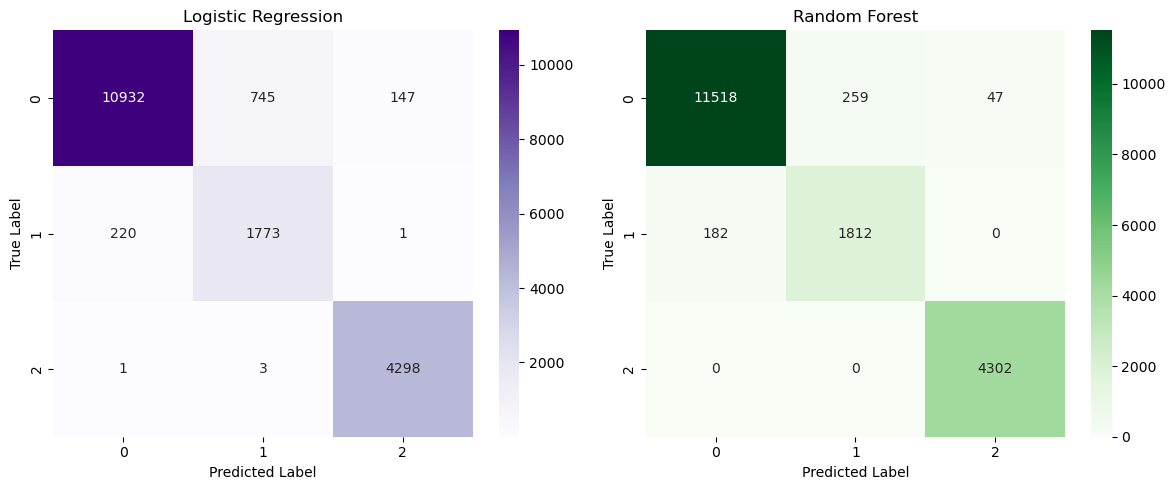

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create subplot for side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Logistic Regression Confusion Matrix
sns.heatmap(
    confusion_matrix(y_test, y_pred_lr),
    annot=True, fmt='d', cmap='Purples', ax=axes[0]
)
axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# Random Forest Confusion Matrix
sns.heatmap(
    confusion_matrix(y_test, y_pred_rf),
    annot=True, fmt='d', cmap='Greens', ax=axes[1]
)
axes[1].set_title("Random Forest")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.show()
